In [42]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [43]:
# Load the dataset

df = pd.read_csv("Ridge_Regression.csv")

In [44]:
df

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
0,67.548412,136.681113,74.904058,11.160537,394.588486,13.926652,-16.522447,0.421922,0.690173,0.130746,-0.231793,-0.007802,0.457751,1.374572,-0.677779,-0.196643,-1.541875,-0.968554,134.043083
1,10.584888,22.233329,10.508898,17.012526,162.191800,28.139002,-16.290166,0.096716,0.782327,-1.113222,0.568251,-1.514520,-2.619945,-0.606891,-0.915810,0.876012,0.664266,-1.219075,-26.813823
2,87.553621,172.345672,94.751066,2.291219,191.159310,3.137131,-10.688365,0.101001,-0.248490,1.399186,-0.635147,0.721966,0.198365,0.762765,1.332185,-0.560118,-0.474221,-0.387968,251.913937
3,75.621412,152.254209,84.322786,49.476168,355.999904,69.945374,13.714077,0.776000,0.033531,0.253237,-0.315592,0.723632,0.580780,2.321409,0.619968,-0.609403,-0.561798,-0.831581,169.374137
4,92.309283,183.101710,101.285729,12.331375,324.547254,18.179052,15.912915,0.399401,0.663990,3.401817,-0.435820,-0.026117,0.460988,0.140603,-1.233827,-1.272347,-0.319837,0.170221,317.867018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,85.933904,168.397963,92.631558,41.669726,278.117956,59.950702,-14.087722,0.861443,1.180555,-0.605156,0.319686,1.735689,1.590589,1.001449,-0.457559,1.093339,0.009035,-1.676065,158.463890
996,51.821150,103.620843,55.285440,33.446798,178.063548,49.890993,9.776528,0.121861,0.073816,1.323277,2.517548,0.165304,-1.916619,-0.398649,0.853120,-0.081948,-0.527589,-0.691923,120.703157
997,20.913632,41.729878,22.685966,2.953540,312.447516,6.905279,14.223410,0.717179,0.859284,0.236330,0.612395,-0.580024,-0.149932,-0.663578,0.830521,0.388768,-0.573233,-1.662678,73.334903
998,54.657041,107.843249,60.379837,45.750630,131.546358,67.311814,3.983354,0.568350,0.189715,0.719818,-1.146777,-1.059161,-0.877698,-0.895878,2.707420,-0.421357,0.577034,-0.889931,80.558724


In [45]:
# the top rows 

df.head()

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
0,67.548412,136.681113,74.904058,11.160537,394.588486,13.926652,-16.522447,0.421922,0.690173,0.130746,-0.231793,-0.007802,0.457751,1.374572,-0.677779,-0.196643,-1.541875,-0.968554,134.043083
1,10.584888,22.233329,10.508898,17.012526,162.191800,28.139002,-16.290166,0.096716,0.782327,-1.113222,0.568251,-1.514520,-2.619945,-0.606891,-0.915810,0.876012,0.664266,-1.219075,-26.813823
2,87.553621,172.345672,94.751066,2.291219,191.159310,3.137131,-10.688365,0.101001,-0.248490,1.399186,-0.635147,0.721966,0.198365,0.762765,1.332185,-0.560118,-0.474221,-0.387968,251.913937
3,75.621412,152.254209,84.322786,49.476168,355.999904,69.945374,13.714077,0.776000,0.033531,0.253237,-0.315592,0.723632,0.580780,2.321409,0.619968,-0.609403,-0.561798,-0.831581,169.374137
4,92.309283,183.101710,101.285729,12.331375,324.547254,18.179052,15.912915,0.399401,0.663990,3.401817,-0.435820,-0.026117,0.460988,0.140603,-1.233827,-1.272347,-0.319837,0.170221,317.867018


In [46]:
# the last rows

df.tail()

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
995,85.933904,168.397963,92.631558,41.669726,278.117956,59.950702,-14.087722,0.861443,1.180555,-0.605156,0.319686,1.735689,1.590589,1.001449,-0.457559,1.093339,0.009035,-1.676065,158.463890
996,51.821150,103.620843,55.285440,33.446798,178.063548,49.890993,9.776528,0.121861,0.073816,1.323277,2.517548,0.165304,-1.916619,-0.398649,0.853120,-0.081948,-0.527589,-0.691923,120.703157
997,20.913632,41.729878,22.685966,2.953540,312.447516,6.905279,14.223410,0.717179,0.859284,0.236330,0.612395,-0.580024,-0.149932,-0.663578,0.830521,0.388768,-0.573233,-1.662678,73.334903
998,54.657041,107.843249,60.379837,45.750630,131.546358,67.311814,3.983354,0.568350,0.189715,0.719818,-1.146777,-1.059161,-0.877698,-0.895878,2.707420,-0.421357,0.577034,-0.889931,80.558724
999,43.004625,88.112896,47.635082,12.315513,360.264609,22.037795,-10.423648,0.487343,0.361479,0.849013,0.331274,-0.322156,-0.249529,0.967376,-0.127555,-0.266029,0.793173,0.888632,76.872214


In [47]:
# describe the dataset 

df.describe

<bound method NDFrame.describe of      feature_1  feature_2_mc  feature_3_mc  feature_4   feature_5  \
0    67.548412    136.681113     74.904058  11.160537  394.588486   
1    10.584888     22.233329     10.508898  17.012526  162.191800   
2    87.553621    172.345672     94.751066   2.291219  191.159310   
3    75.621412    152.254209     84.322786  49.476168  355.999904   
4    92.309283    183.101710    101.285729  12.331375  324.547254   
..         ...           ...           ...        ...         ...   
995  85.933904    168.397963     92.631558  41.669726  278.117956   
996  51.821150    103.620843     55.285440  33.446798  178.063548   
997  20.913632     41.729878     22.685966   2.953540  312.447516   
998  54.657041    107.843249     60.379837  45.750630  131.546358   
999  43.004625     88.112896     47.635082  12.315513  360.264609   

     feature_6_mc  feature_7  feature_8   noise_1   noise_2   noise_3  \
0       13.926652 -16.522447   0.421922  0.690173  0.130746 -0.2

In [48]:
# information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   feature_1     1000 non-null   float64
 1   feature_2_mc  1000 non-null   float64
 2   feature_3_mc  1000 non-null   float64
 3   feature_4     1000 non-null   float64
 4   feature_5     1000 non-null   float64
 5   feature_6_mc  1000 non-null   float64
 6   feature_7     1000 non-null   float64
 7   feature_8     1000 non-null   float64
 8   noise_1       1000 non-null   float64
 9   noise_2       1000 non-null   float64
 10  noise_3       1000 non-null   float64
 11  noise_4       1000 non-null   float64
 12  noise_5       1000 non-null   float64
 13  noise_6       1000 non-null   float64
 14  noise_7       1000 non-null   float64
 15  noise_8       1000 non-null   float64
 16  noise_9       1000 non-null   float64
 17  noise_10      1000 non-null   float64
 18  target        1000 non-null  

In [49]:
# Total column names
df.columns

Index(['feature_1', 'feature_2_mc', 'feature_3_mc', 'feature_4', 'feature_5',
       'feature_6_mc', 'feature_7', 'feature_8', 'noise_1', 'noise_2',
       'noise_3', 'noise_4', 'noise_5', 'noise_6', 'noise_7', 'noise_8',
       'noise_9', 'noise_10', 'target'],
      dtype='object')

In [50]:
# shape of the dataset 

df.shape

(1000, 19)

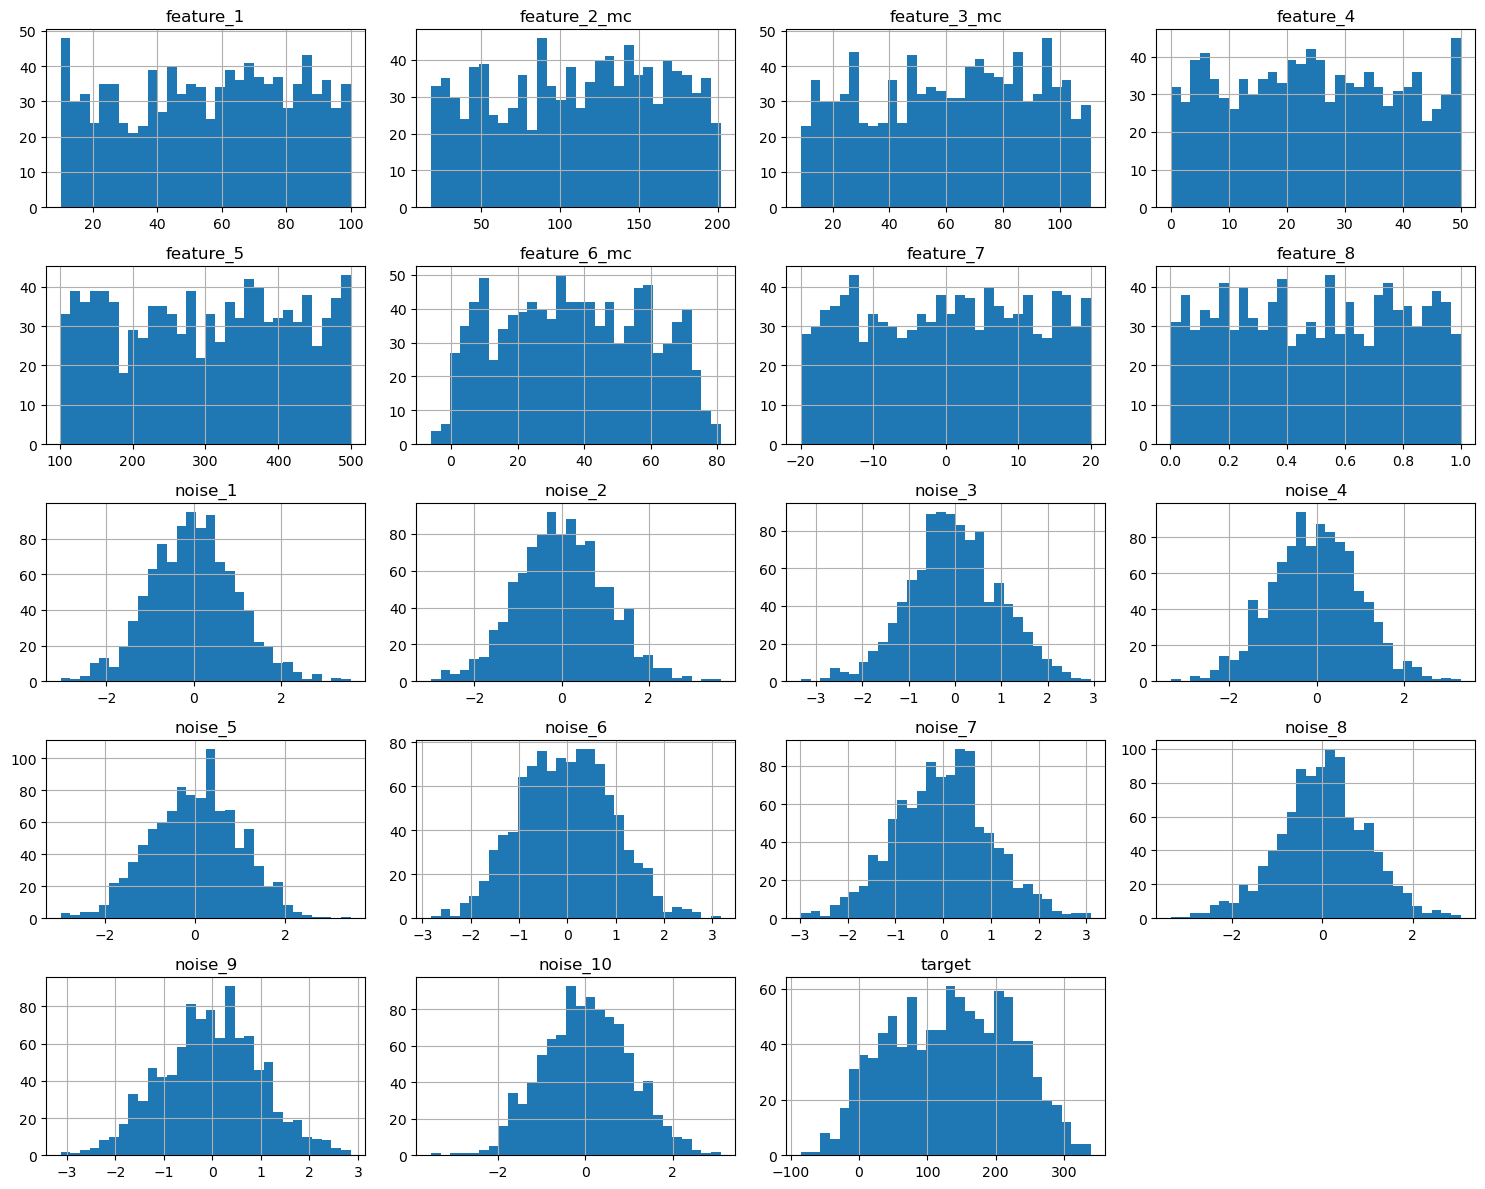

In [51]:
# EDA 

df.hist(figsize=(15,12), bins = 30)
plt.tight_layout()
plt.show()

In [52]:
# split the data into X and y

X = df.drop("target", axis = 1)
y = df["target"]

In [53]:
# Check the shape of X and y

print(X.shape)
print(y.shape)

(1000, 18)
(1000,)


# Linear Regression

In [54]:
# Train Test and Spilt the data

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42
)

In [55]:
# Linear Regression

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# Train the model using the training datasets
linear_model.fit(X_train,y_train)

# Predict the test datasets
y_pred = linear_model.predict(X_test)

In [56]:
# Model Evalution

from sklearn.metrics import mean_squared_error, r2_score

# calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)

# calculate the mean absolute error
mae = mean_squared_error(y_test,y_pred)

# calculate the R-Squared value
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:",mse)
print("R-Squared Value:", r2)
print("Mean Absolute Error:",mae)

Mean Squared Error: 260.68518230530776
R-Squared Value: 0.9674605691991364
Mean Absolute Error: 260.68518230530776


# Ridge Regression

In [57]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [58]:
print(df.shape)

(1000, 19)


In [59]:
# Standardization


scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)

X_test_scaled = scalar.transform(X_test)

In [60]:
scalar.fit_transform(X_train)

array([[ 0.43802629,  0.49105607,  0.50406473, ...,  1.58673372,
        -1.17660089, -1.43189729],
       [ 0.23344389,  0.22053151,  0.25279399, ...,  0.31435517,
         0.75084413,  1.5244298 ],
       [-0.52261277, -0.57508472, -0.51591864, ..., -0.26840981,
        -1.48570034,  1.02191977],
       ...,
       [-1.69434009, -1.68243303, -1.71110777, ...,  0.06733033,
         0.62410099, -0.76927864],
       [ 1.01940761,  1.03679243,  1.06528801, ..., -1.13732042,
        -1.25442459, -0.17470353],
       [ 1.5045209 ,  1.54120969,  1.5303376 , ..., -0.39899932,
        -0.31751768,  0.49510861]], shape=(800, 18))

In [61]:
scalar.transform(X_test)

array([[ 1.50611558,  1.43954318,  1.47731024, ..., -0.36117456,
         0.1493438 , -1.37926571],
       [-1.22877703, -1.20471593, -1.22799513, ..., -1.11897615,
         0.25073382,  0.85526766],
       [-1.6032227 , -1.55961002, -1.58504456, ...,  1.28091816,
         2.82866418,  0.93116914],
       ...,
       [ 1.15517101,  1.16503524,  1.16151986, ..., -1.524404  ,
        -0.0496191 ,  0.39677389],
       [-1.21333972, -1.20688457, -1.22847774, ...,  0.34474532,
         0.66943739, -0.2903814 ],
       [-1.46570757, -1.48011344, -1.49347624, ..., -0.77776656,
         0.50402891, -1.44956878]], shape=(200, 18))

In [62]:
# create the ridge regression model

ridge_model = Ridge(alpha=1.0)


In [63]:
# Train the model

ridge_model.fit(X_train_scaled,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [64]:
# make the prediction

y_pred = ridge_model.predict(X_test_scaled)

In [68]:
# Evaluate Ridge Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Ridge Regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Ridge Regression
MAE : 12.968028503183168
MSE : 257.06990939365926
RMSE: 16.03339980770327
R²  : 0.967911837359814


# Laso Regression

In [69]:
from sklearn.linear_model import Lasso

In [70]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
scaler.fit_transform(X_train)

array([[ 0.43802629,  0.49105607,  0.50406473, ...,  1.58673372,
        -1.17660089, -1.43189729],
       [ 0.23344389,  0.22053151,  0.25279399, ...,  0.31435517,
         0.75084413,  1.5244298 ],
       [-0.52261277, -0.57508472, -0.51591864, ..., -0.26840981,
        -1.48570034,  1.02191977],
       ...,
       [-1.69434009, -1.68243303, -1.71110777, ...,  0.06733033,
         0.62410099, -0.76927864],
       [ 1.01940761,  1.03679243,  1.06528801, ..., -1.13732042,
        -1.25442459, -0.17470353],
       [ 1.5045209 ,  1.54120969,  1.5303376 , ..., -0.39899932,
        -0.31751768,  0.49510861]], shape=(800, 18))

In [73]:
# create the Lasso Regression model

lasso_model = Lasso(alpha=1.0)

In [74]:
# Train the lasso model

lasso_model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [75]:
# make prediction

y_pred_lasso = lasso_model.predict(X_test_scaled)

In [76]:
# Evaluate lasso regression

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)

rmse_lasso = np.sqrt(mse_lasso)

r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression")
print("-------------------------")
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R²  :", r2_lasso)

Lasso Regression
-------------------------
MAE : 13.018044700750497
MSE : 266.61380664136266
RMSE: 16.328313037217367
R²  : 0.96672054224547


# Polynomial Regression

In [82]:
from sklearn.preprocessing import PolynomialFeatures

poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)

X_test_poly2 =  poly2.transform(X_test)

In [83]:
poly2.fit_transform(X_train)

array([[ 6.64518156e+01,  1.35663528e+02,  7.49529664e+01, ...,
         1.53038140e+00,  1.74879564e+00,  1.99838171e+00],
       [ 6.11596968e+01,  1.21643074e+02,  6.77799518e+01, ...,
         5.29342174e-01,  1.12132125e+00,  2.37532813e+00],
       [ 4.16020922e+01,  8.04087388e+01,  4.58355466e+01, ...,
         2.40917255e+00, -1.61260845e+00,  1.07941874e+00],
       ...,
       [ 1.12919569e+01,  2.30182909e+01,  1.17165354e+01, ...,
         3.58046374e-01, -4.49587176e-01,  5.64531980e-01],
       [ 8.14909343e+01,  1.63947360e+02,  9.09741827e+01, ...,
         1.73293939e+00,  2.06775538e-01,  2.46726017e-02],
       [ 9.40398006e+01,  1.90089751e+02,  1.04249933e+02, ...,
         1.30626037e-01, -1.85193704e-01,  2.62556445e-01]],
      shape=(800, 189))

In [84]:
poly2.transform(X_test)

array([[ 9.40810518e+01,  1.84820690e+02,  1.02736163e+02, ...,
         1.30987363e-02, -1.55770175e-01,  1.85241895e+00],
       [ 2.33350997e+01,  4.77768951e+01,  2.55079305e+01, ...,
         4.74353444e-02,  1.90001776e-01,  7.61050125e-01],
       [ 1.36489732e+01,  2.93838290e+01,  1.53152563e+01, ...,
         8.09676347e+00,  2.69821466e+00,  8.99169449e-01],
       ...,
       [ 8.50028497e+01,  1.70593790e+02,  9.37213089e+01, ...,
         7.80628747e-03, -3.65885601e-02,  1.71492881e-01],
       [ 2.37344304e+01,  4.76645011e+01,  2.54941534e+01, ...,
         4.15484874e-01, -1.75774228e-01,  7.43627051e-02],
       [ 1.72062020e+01,  3.35038914e+01,  1.79292530e+01, ...,
         2.26557228e-01, -6.81272462e-01,  2.04863103e+00]],
      shape=(200, 189))

In [86]:
# Train polynomial Regression -- Degree 2 

poly_model2 = LinearRegression()

poly_model2.fit(X_train_poly2, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
y_pred_poly2 = poly_model2.predict(X_test_poly2)

In [89]:
# Evaluate Degree 2 

mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)

mse_poly2 = mean_squared_error(y_test, y_pred_poly2)

rmse_poly2 = np.sqrt(mse_poly2)

r2_poly2 = r2_score(y_test, y_pred_poly2)

print("Polynomial Regression - Degree 2")
print("MAE :", mae_poly2)
print("MSE :", mse_poly2)
print("RMSE:", rmse_poly2)
print("R²  :", r2_poly2)


Polynomial Regression - Degree 2
MAE : 14.52148758834791
MSE : 335.1456964960227
RMSE: 18.306984910028813
R²  : 0.9581662060616573
